<a href="https://colab.research.google.com/github/LisethTiria/Biosenales-2025-1/blob/main/Practica6/FiltrosDigitales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="display: flex; align-items: center; gap: 20px; background-color: rgba(9, 169, 36, 0.72); padding: 20px; border-radius: 10px; color: white;">
  <img src="logo_udea.png" alt="Logo UdeA" style="height: 80px;">
  <div>
    <h1 style="margin: 0; font-size: 2em;">Práctica 6: Diseño de Filtros Digitales</h1>
    <p style="margin: 2px 0 0 0; font-size: 1.3em;"><strong>Bioseñales y Sistemas</strong></p>
    <p style="margin: 10px 0 0 0; font-size: 1.2em;">Universidad de Antioquia - Facultad de Ingeniería</p>
    <p style="margin: 5px 0 0 0; font-size: 1em;">Integrantes: Luisa Taho, Liseth Tiria, Victor Ocampo</p>
    <p style="margin: 5px 0 0 0; font-size: 1em;">Profesores: John Fredy Ochoa, Juliana Moreno Rada</p>
  </div>
</div>

# Creación de la señal

Se creará una secuencia sinusoidal $𝑥_e(𝑛)$, con $0≤𝑛≤1000, 𝐹_0=0,01$ Hz y $𝐹_𝑠=25$ Hz generada por un proceso electrofisiológico.

El viaje de la señal hipotética $𝑥_𝑒(𝑛)$ a través de los diversos tejidos genera una atenuación en la amplitud y un retraso temporal. La señal registrada finalmente es de la forma: $𝑦_𝑒(𝑛)=\alpha 𝑥_𝑒(𝑛−𝐷)+𝑤(𝑛)$

Donde $\alpha\$ representa la amplitud, D es un retraso debido a la conducción a través de los diversos tejidos y 𝑤(𝑛) representa el ruido generado por la electrónica de los sistemas de adquisición.

la señal 𝑤(𝑛) fue implementada como una secuencia de ruido Gaussiano con media cero y varianza $𝜎^2=0,01$, establezca $\alpha=0,8$ y un retraso 𝐷=15 muestras. Grafique ambas señales.



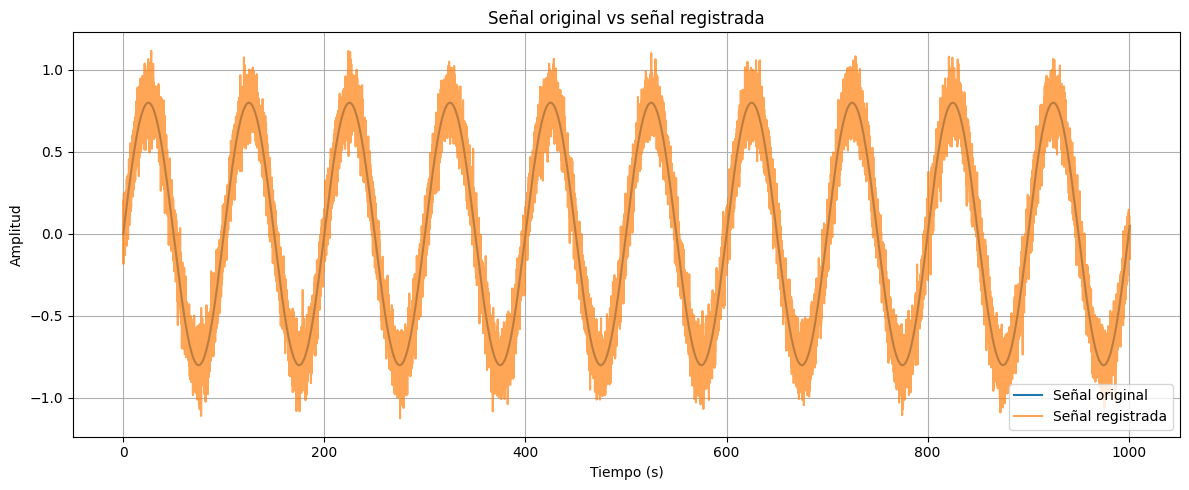

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros de la señal
fs = 25  # Frecuencia de muestreo (Hz)
f = 0.01    # Frecuencia de la señal (Hz)
alpha = 0.8  # Amplitud original
D = 15    # Número de muestras de retraso
n = np.arange(0, 1001, 1/fs)

# Señal original
x = alpha * np.sin(2 * np.pi * f * n)

# Ruido gaussiano
m = np.random.normal(0, 0.1, len(n))  # media=0, varianza=0.01

# Señal retrasada
x_e = np.zeros_like(x)
x_e[D:] = x[:-D]

# Señal con ruido y retraso (señal registrada)
y_e = x_e + m

# Graficar señales
plt.figure(figsize=(12, 5))
plt.plot(n, x, label='Señal original')
plt.plot(n, y_e, label='Señal registrada', alpha=0.7)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Señal original vs señal registrada")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


# Diseño de filtros digitales

## Filtros FIR usando la función *firwin*




filtro FIR pasa bajas para la señal $𝑦_𝑒(𝑛)$, con una frecuencia de corte de 1.25 muestras/s y orden 30.


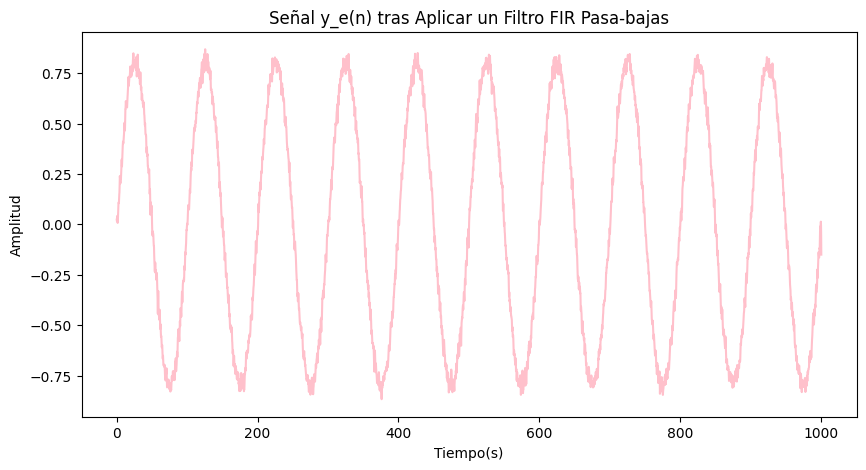

In [11]:
import scipy.signal as signal

# Definir parámetros del filtro
fc_pb = 1.25  # Frecuencia de corte en Hz
orden_fir = 30
nyquist = fs / 2
Wn_pb = fc_pb / nyquist  # Frecuencia normalizada

# Diseño del filtro pasa bajas FIR
fir_pb = signal.firwin(numtaps=orden_fir + 1, cutoff=Wn_pb, window='hamming')

#filtrado de la señal
y_e_fpb=signal.filtfilt(b=fir_pb,a=1,x=y_e) # Aplicación del filtro

# Graficamos
plt.figure(figsize=(10, 5))
plt.plot(n,y_e_fpb,color='pink')
plt.xlabel("Tiempo(s)")
plt.ylabel("Amplitud")
plt.title("Señal y_e(n) filtrada mediante FIR Pasa-bajas")

plt.show()


Filtro FIR pasa altas para la señal $𝑦_𝑒(𝑛)$, con una frecuencia de corte de 1.25 y 7.5 muestras/s y orden 30.


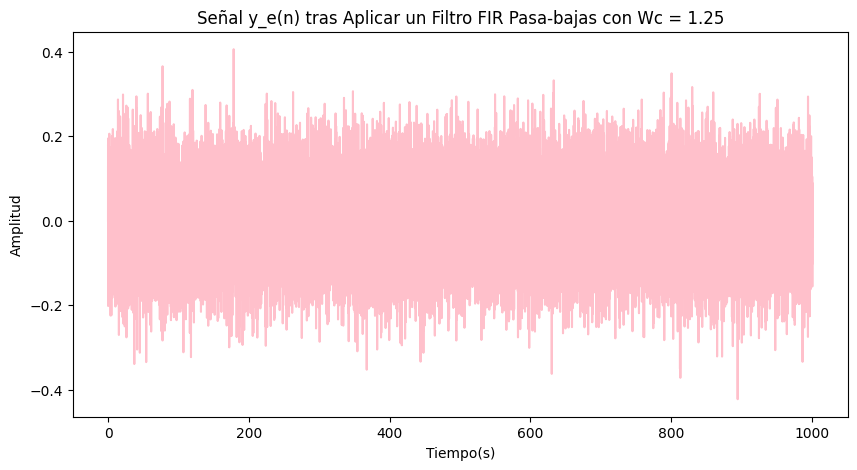

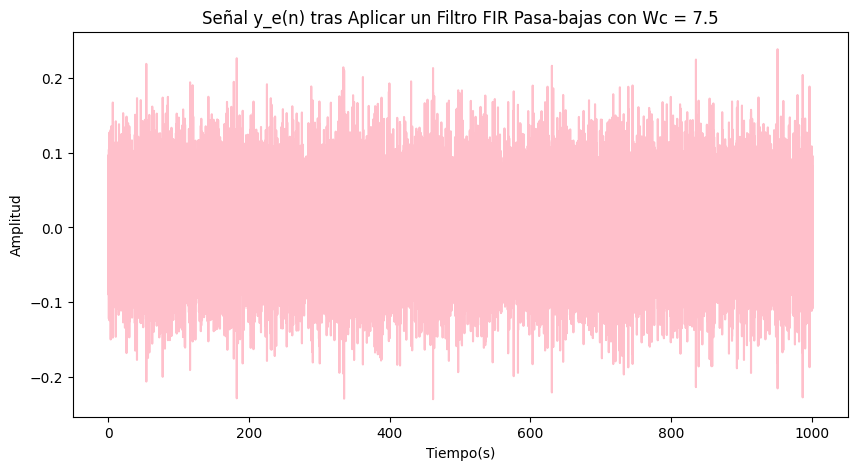

In [17]:
# Frecuencia de corte para pasa altas
fc_pa = [1.25, 7.5]
for f in fc_pa:
  Wn_pa = [f / nyquist]

  # Diseño del filtro pasa altas FIR
  fir_pa = signal.firwin(numtaps=orden_fir + 1, cutoff=Wn_pa, window='hamming', pass_zero=False)

  #filtrado de la señal
  y_e_fpa=signal.filtfilt(b=fir_pa,a=1,x=y_e) # Aplicación del filtro
  # Graficamos
  plt.figure(figsize=(10, 5))
  plt.plot(n,y_e_fpa,color='pink')
  plt.xlabel("Tiempo(s)")
  plt.ylabel("Amplitud")
  plt.title("Señal y_e(n) filtrada mediante FIR Pasa-altas con Wc = " + str(f))

  plt.show()


Filtro FIR pasa banda para la señal $𝑦_𝑒(𝑛)$, con una frecuencia de corte de 1.25 y 7.5 muestras/s y orden 30.


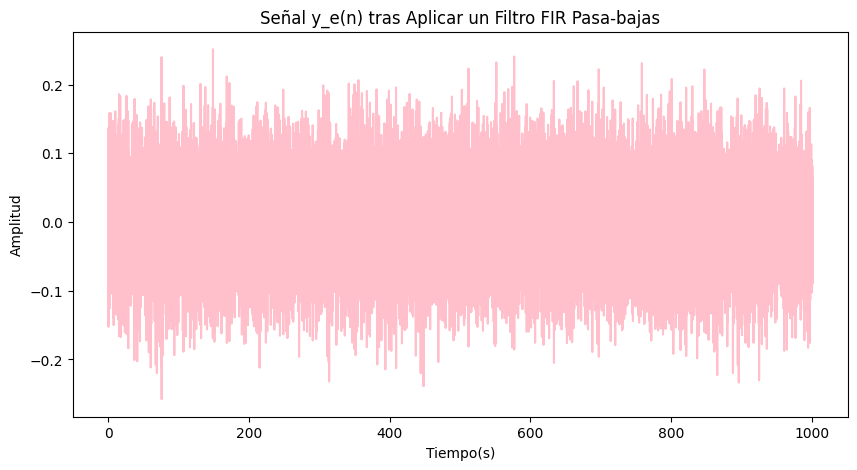

In [19]:
# Rango de frecuencias para el filtro pasa banda
fc_inferior = 1.25
fc_superior = 7.5

# Diseño del filtro pasa banda FIR
Wn_pbanda = [fc_inferior / nyquist, fc_superior / nyquist]


# Diseño del filtro pasa banda FIR
fir_pbanda = signal.firwin(numtaps=orden_fir + 1, cutoff=[Wn_pbanda[0], Wn_pbanda[1]], window='hamming', pass_zero=False)

#filtrado de la señal
y_e_fpbanda=signal.filtfilt(b=fir_pbanda,a=1,x=y_e) # Aplicación del filtro

# Graficamos
plt.figure(figsize=(10, 5))
plt.plot(n,y_e_fpbanda,color='pink')
plt.xlabel("Tiempo(s)")
plt.ylabel("Amplitud")
plt.title("Señal y_e(n) filtrada mediante FIR Pasa-banda")

plt.show()



## Comparación de la señal registrada y la señal filtrada


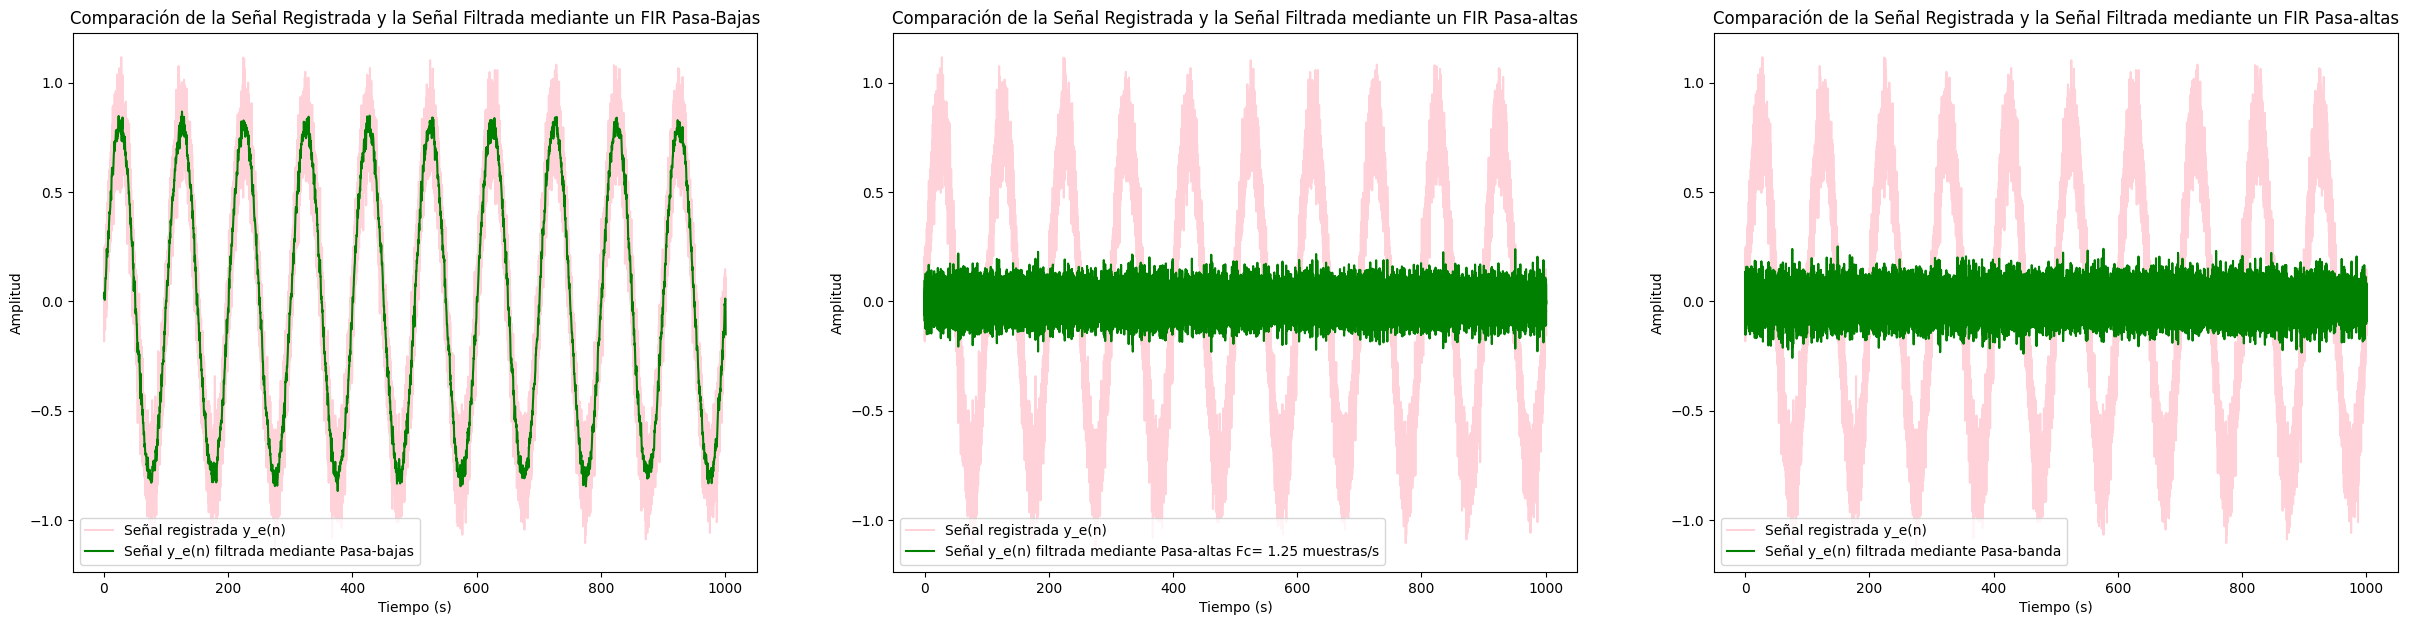

In [27]:
plt.figure(figsize=(30, 7))

plt.subplot(1,3,1)
plt.plot(n, y_e, label='Señal registrada y_e(n)', color='pink', alpha=0.7)
plt.plot(n, y_e_fpb, label='Señal y_e(n) filtrada mediante Pasa-bajas', color='green')
plt.title('Comparación de la Señal Registrada y la Señal Filtrada mediante un FIR Pasa-Bajas')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()

plt.subplot(1,3,2)

plt.plot(n, y_e, label='Señal registrada y_e(n)', color='pink', alpha=0.7)
plt.plot(n, y_e_fpa, label='Señal y_e(n) filtrada mediante Pasa-altas Fc= 1.25 muestras/s', color='green')
plt.title('Comparación de la Señal Registrada y la Señal Filtrada mediante un FIR Pasa-altas')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()

plt.subplot(1,3,3)

plt.plot(n, y_e, label='Señal registrada y_e(n)', color='pink', alpha=0.7)
plt.plot(n, y_e_fpbanda, label='Señal y_e(n) filtrada mediante Pasa-banda', color='green')
plt.title('Comparación de la Señal Registrada y la Señal Filtrada mediante un FIR Pasa-altas')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()



plt.show()

## Filtros IIR usando la función *iirfilter*

Filtro IIR pasa bajas para la señal $𝑦_𝑒(𝑛)$, con una frecuencia de corte de 1.25 muestras/s y orden 30.

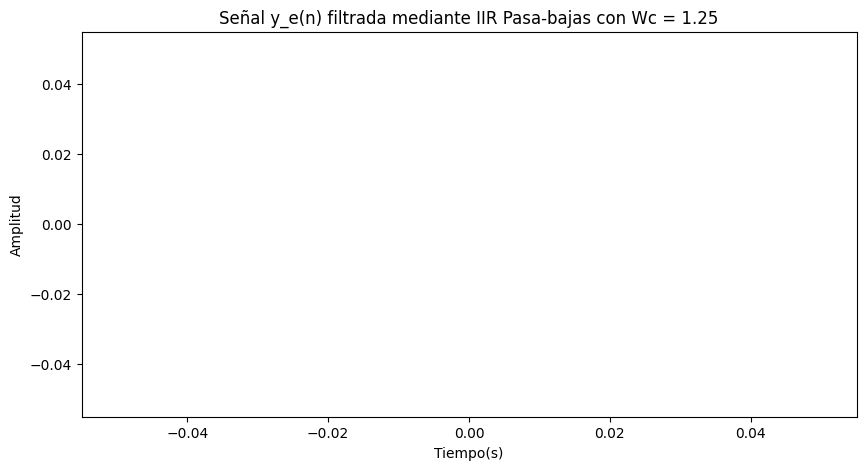

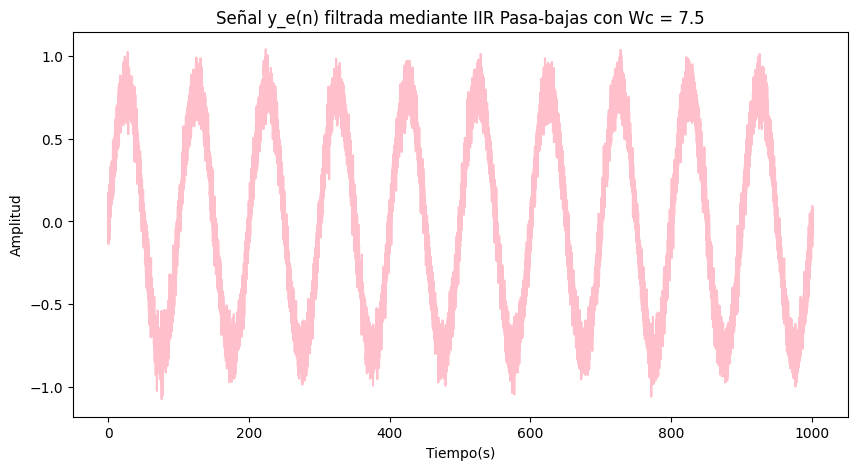

In [45]:
# Definir parámetros del filtro
fc_pb = [1.25, 7.5]  # Frecuencia de corte en Hz
orden_iir = 30
nyquist = fs / 2
for f in fc_pb:
  Wn_pb = f / nyquist  # Frecuencia normalizada

  # Diseño del filtro pasa bajas FIR
  b_iir_pb, a_iir_pb = signal.iirfilter(orden_iir, Wn_pb, btype='low', ftype='butter')

  #filtrado de la señal
  y_e_ipb=signal.filtfilt(b=b_iir_pb,a=a_iir_pb,x=y_e) # Aplicación del filtro

  # Graficamos
  plt.figure(figsize=(10, 5))
  plt.plot(n,y_e_ipb,color='pink')
  plt.xlabel("Tiempo(s)")
  plt.ylabel("Amplitud")
  plt.title("Señal y_e(n) filtrada mediante IIR Pasa-bajas con Wc = " + str(f))
  plt.show()


Filtro IIR pasa altas para la señal $𝑦_𝑒(𝑛)$, con una frecuencia de corte de 1.25 y 7.5 muestras/s y orden 30.

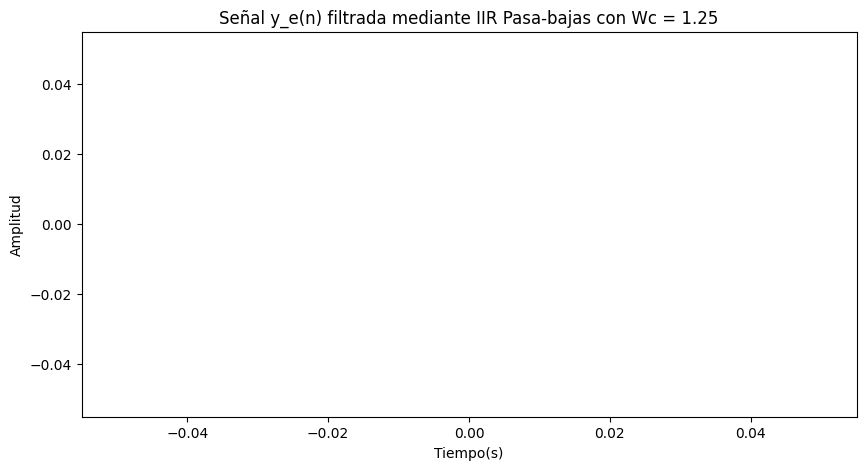

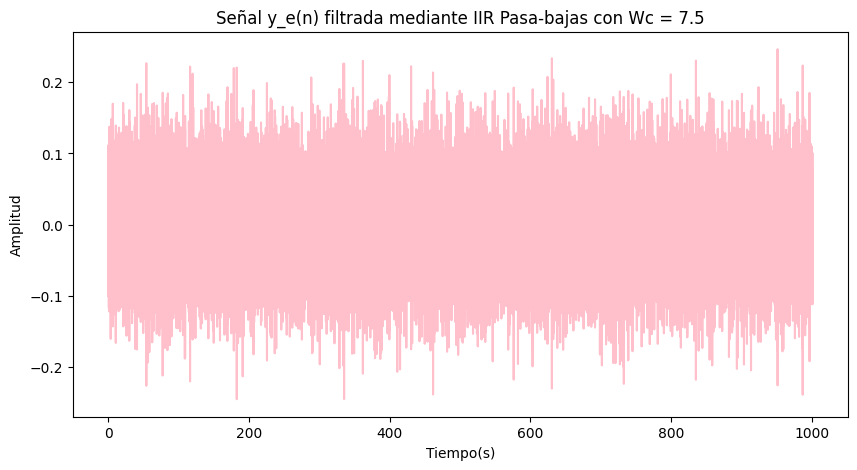

In [46]:
# Definir parámetros del filtro
fc_pb = [1.25, 7.5]  # Frecuencia de corte en Hz
orden_iir = 30
nyquist = fs / 2
for f in fc_pb:
  Wn_pb = f / nyquist  # Frecuencia normalizada

  # Diseño del filtro pasa bajas FIR
  b_iir_pa, a_iir_pa = signal.iirfilter(orden_iir, Wn_pb, btype='high', ftype='butter')

  #filtrado de la señal
  y_e_ipa=signal.filtfilt(b=b_iir_pa,a=a_iir_pa,x=y_e) # Aplicación del filtro

  # Graficamos
  plt.figure(figsize=(10, 5))
  plt.plot(n,y_e_ipa,color='pink')
  plt.xlabel("Tiempo(s)")
  plt.ylabel("Amplitud")
  plt.title("Señal y_e(n) filtrada mediante IIR Pasa-bajas con Wc = " + str(f))
  plt.show()


Filtro IIR pasa banda para la señal $𝑦_𝑒(𝑛)$, con una frecuencia de corte de 1.25 y 7.5 muestras/s y orden 30.

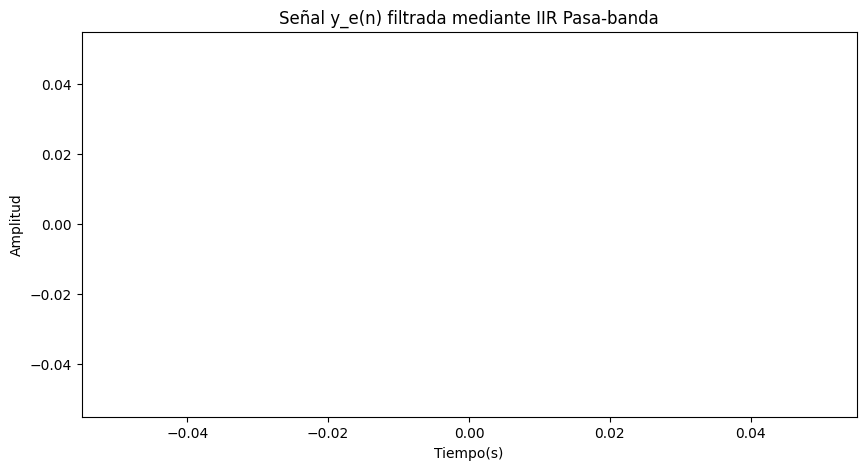

In [43]:
# Rango de frecuencias para el filtro pasa banda IIR
fc_inferior_iir = 1.25
fc_superior_iir = 7.5

# Frecuencias normalizadas para el filtro pasa banda IIR
Wn_pbanda_iir = [fc_inferior_iir / nyquist, fc_superior_iir / nyquist]

# Diseño del filtro pasa banda IIR
b_iir_pbanda, a_iir_pbanda = signal.iirfilter(orden_iir, Wn_pbanda_iir, ftype='butter', btype='band')

# Filtrado de la señal
y_e_ipbanda = signal.filtfilt(b=b_iir_pbanda, a=a_iir_pbanda, x=y_e)

# Graficamos
plt.figure(figsize=(10, 5))
plt.plot(n, y_e_ipbanda, color='pink')
plt.xlabel("Tiempo(s)")
plt.ylabel("Amplitud")
plt.title("Señal y_e(n) filtrada mediante IIR Pasa-banda")
plt.show()

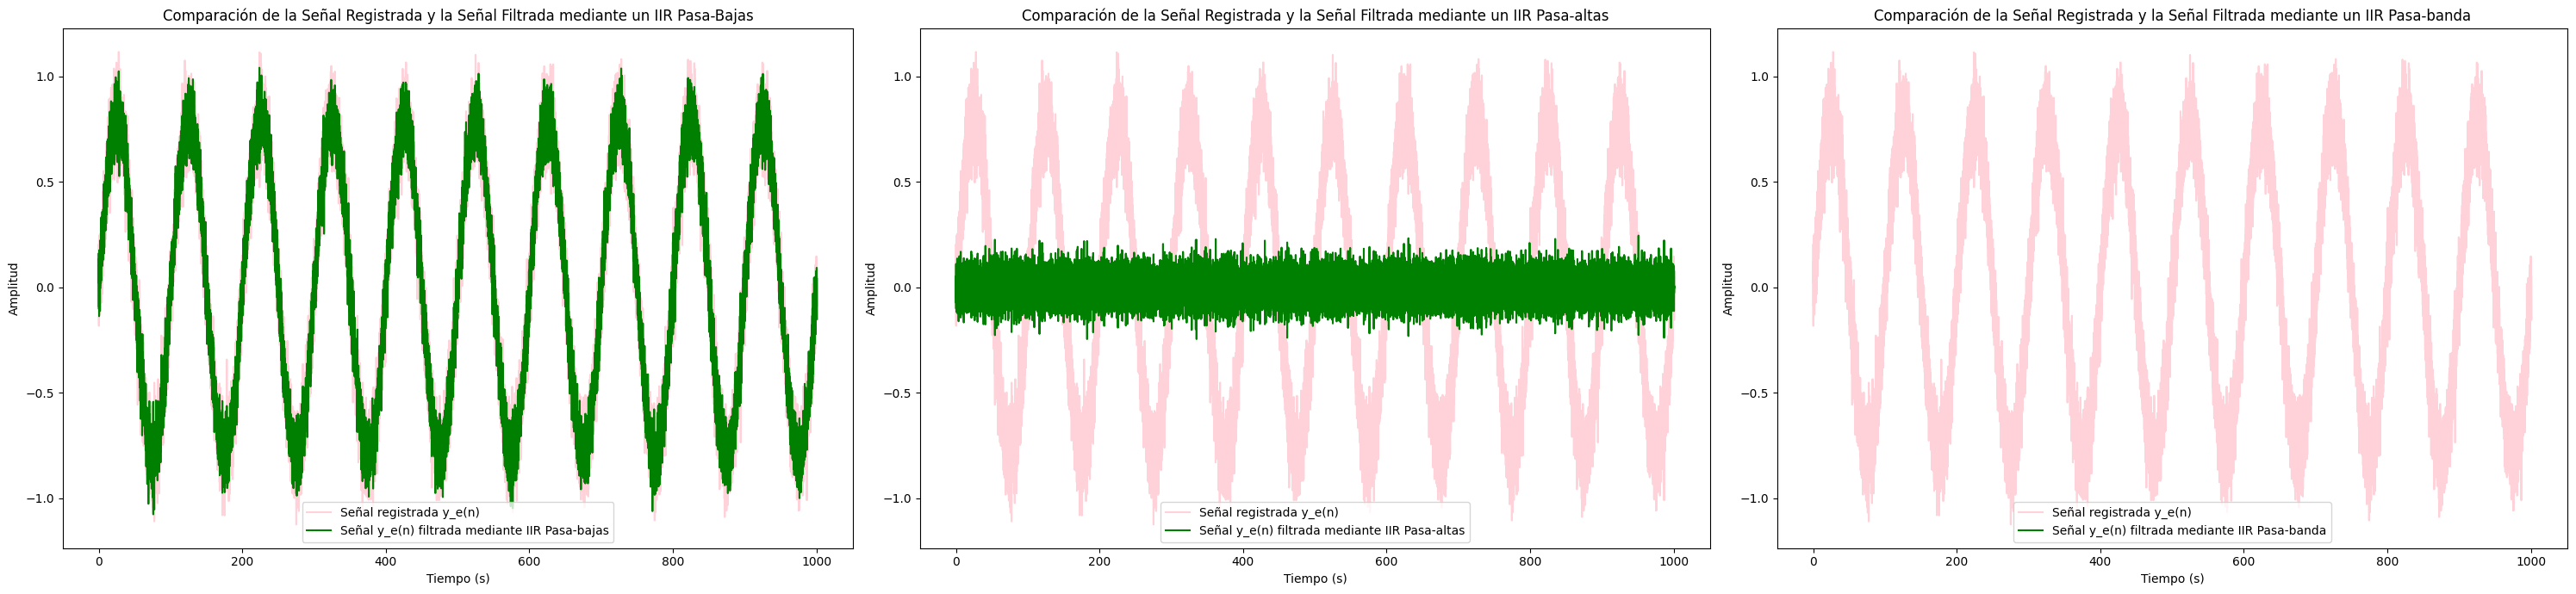

In [47]:
plt.figure(figsize=(30, 7))

plt.subplot(1, 3, 1)
plt.plot(n, y_e, label='Señal registrada y_e(n)', color='pink', alpha=0.7)
plt.plot(n, y_e_ipb, label='Señal y_e(n) filtrada mediante IIR Pasa-bajas', color='green')
plt.title('Comparación de la Señal Registrada y la Señal Filtrada mediante un IIR Pasa-Bajas')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(n, y_e, label='Señal registrada y_e(n)', color='pink', alpha=0.7)
# Assuming y_e_ipa from the previous high-pass filter implementation for the first frequency
plt.plot(n, y_e_ipa, label='Señal y_e(n) filtrada mediante IIR Pasa-altas', color='green')
plt.title('Comparación de la Señal Registrada y la Señal Filtrada mediante un IIR Pasa-altas')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(n, y_e, label='Señal registrada y_e(n)', color='pink', alpha=0.7)
plt.plot(n, y_e_ipbanda, label='Señal y_e(n) filtrada mediante IIR Pasa-banda', color='green')
plt.title('Comparación de la Señal Registrada y la Señal Filtrada mediante un IIR Pasa-banda')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()

plt.tight_layout()
plt.show()